* Name - Sharvil Vichare
* Roll NO - B39
* PRN - 2324000814

In [ ]:
# import the necessary packages
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import AveragePooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from imutils import paths
import matplotlib.pyplot as plt
import numpy as np
import argparse
import cv2
import os
from keras.applications.resnet50 import ResNet50
from keras.preprocessing import image
from keras.applications.resnet50 import preprocess_input, decode_predictions
import numpy as np


In [ ]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from PIL import Image
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Conv2D, MaxPool2D, Flatten
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
!git clone https://github.com/vaibhavG321/Classification-of-COVID-19-chest-X-ray-images

Cloning into 'Classification-of-COVID-19-chest-X-ray-images'...
remote: Enumerating objects: 901, done.
remote: Counting objects: 100% (245/245), done.
remote: Compressing objects: 100% (166/166), done.
remote: Total 901 (delta 58), reused 224 (delta 48), pack-reused 656 (from 1)
Receiving objects: 100% (901/901), 235.19 MiB | 19.76 MiB/s, done.
Resolving deltas: 100% (86/86), done.
Updating files: 100% (807/807), done.


In [ ]:
!ls

Classification-of-COVID-19-chest-X-ray-images  sample_data


In [ ]:
cd Classification-of-COVID-19-chest-X-ray-images

/content/Classification-of-COVID-19-chest-X-ray-images


In [ ]:
!ls

 aditi-godbole-model.py		    covid19_project_pruning.ipynb
 aditi-verma-model.py		    covid_VGG16.ipynb
 aditya-babar-model.py		    dataset
 aditya-gurnani-model.py	   'ionic application'
 augmentation.ipynb		    README.md
 covid19_internship_project.ipynb   test1.ipynb
 covid19_project.ipynb		    vaibhav-model.py


In [ ]:
cd dataset

/content/Classification-of-COVID-19-chest-X-ray-images/dataset


In [ ]:
!ls

evaluation  testing  training


In [ ]:
cd training

/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training


In [ ]:
!ls

infected  normal


In [ ]:
train_normal_path='/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/normal'
train_infected_path='/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/infected'
test_normal_path='/content/Classification-of-COVID-19-chest-X-ray-images/dataset/testing/normal'
test_infected_path='/content/Classification-of-COVID-19-chest-X-ray-images/dataset/testing/infected'
evaluate_normal_path='/content/Classification-of-COVID-19-chest-X-ray-images/dataset/evaluation/normal'
evaluate_infected_path='/content/Classification-of-COVID-19-chest-X-ray-images/dataset/evaluation/infected'

In [ ]:
print('train_normal cases ',len(os.listdir('/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/normal')))
print('train_infected cases ',len(os.listdir('/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/infected')))
print('test_normal cases ',len(os.listdir('/content/Classification-of-COVID-19-chest-X-ray-images/dataset/testing/normal')))
print('test_infected cases ',len(os.listdir('/content/Classification-of-COVID-19-chest-X-ray-images/dataset/testing/infected')))
print('evaluate_normal cases ',len(os.listdir('/content/Classification-of-COVID-19-chest-X-ray-images/dataset/evaluation/normal')))
print('evaluate_infected cases ',len(os.listdir('/content/Classification-of-COVID-19-chest-X-ray-images/dataset/evaluation/infected')))

train_normal cases  297
train_infected cases  296
test_normal cases  69
test_infected cases  25
evaluate_normal cases  1
evaluate_infected cases  1


In [ ]:
IMAGE_SIZE = (224,224)
DIR_NAME = '/content/Classification-of-COVID-19-chest-X-ray-images/dataset/'
IMAGE_DIR = DIR_NAME + 'normal/'
imagePaths=[]
for dirname, _, filenames in os.walk(DIR_NAME):
    for filename in filenames:
      imagePaths.append(os.path.join(dirname, filename))

In [ ]:
imagePaths

['/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/infected/covid_train (15).jpg',
 '/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/infected/covid_train (57).jpg',
 '/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/infected/covid_train (11).jpeg',
 '/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/infected/covid_train (14).jpg',
 '/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/infected/covid_train (106).jpg',
 '/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/infected/covid_train (43).jpeg',
 '/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/infected/covid_train (25).jpg',
 '/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/infected/covid_train (32).jpg',
 '/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/infected/covid_train24.jpeg',
 '/content/Classification-of-COVID-19-chest-X

In [ ]:
data = []
labels = []
# loop over the image paths
for imagePath in imagePaths:
	# extract the class label from the filename
	label = imagePath.split(os.path.sep)[-2]
	# load the image, swap color channels, and resize it to be a fixed
	# 224x224 pixels while ignoring aspect ratio
	image = cv2.imread(imagePath)
	image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
	image = cv2.resize(image, (224, 224))
	# update the data and labels lists, respectively
	data.append(image)
	labels.append(label)
# convert the data and labels to NumPy arrays while scaling the pixel
# intensities to the range [0, 1]
data = np.array(data) / 255.0
labels = np.array(labels)

In [ ]:
data.shape

(689, 224, 224, 3)

In [ ]:
labels


array(['infected', 'infected', 'infected', 'infected', 'infected',
       'infected', 'infected', 'infected', 'infected', 'infected',
       'infected', 'infected', 'infected', 'infected', 'infected',
       'infected', 'infected', 'infected', 'infected', 'infected',
       'infected', 'infected', 'infected', 'infected', 'infected',
       'infected', 'infected', 'infected', 'infected', 'infected',
       'infected', 'infected', 'infected', 'infected', 'infected',
       'infected', 'infected', 'infected', 'infected', 'infected',
       'infected', 'infected', 'infected', 'infected', 'infected',
       'infected', 'infected', 'infected', 'infected', 'infected',
       'infected', 'infected', 'infected', 'infected', 'infected',
       'infected', 'infected', 'infected', 'infected', 'infected',
       'infected', 'infected', 'infected', 'infected', 'infected',
       'infected', 'infected', 'infected', 'infected', 'infected',
       'infected', 'infected', 'infected', 'infected', 'infect

In [ ]:
# perform one-hot encoding on the labels
lb = LabelBinarizer()
labels = lb.fit_transform(labels)
labels = to_categorical(labels)
# partition the data into training and testing splits using 80% of
# the data for training and the remaining 20% for testing
(trainX, testX, trainY, testY) = train_test_split(data, labels,
	test_size=0.20, stratify=labels, random_state=42)
# initialize the training data augmentation object
trainAug = ImageDataGenerator(shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,	rotation_range=15,
	fill_mode="nearest")

In [ ]:
trainAug

In [ ]:
trainX.shape,testX.shape,trainY.shape,testY.shape

((551, 224, 224, 3), (138, 224, 224, 3), (551, 2), (138, 2))

USING VGG16 MODEL

In [ ]:
baseModel = VGG16(weights="imagenet", include_top=False,
	input_tensor=Input(shape=(224, 224, 3)))
# construct the head of the model that will be placed on top of the
# the base model
headModel = baseModel.output
headModel = AveragePooling2D(pool_size=(4, 4))(headModel)
headModel = Flatten(name="flatten")(headModel)
headModel = Dense(64, activation="relu")(headModel)
headModel = Dropout(0.5)(headModel)
headModel = Dense(2, activation="softmax")(headModel)
# place the head FC model on top of the base model (this will become
# the actual model we will train)
model = Model(inputs=baseModel.input, outputs=headModel)
# loop over all layers in the base model and freeze them so they will
# *not* be updated during the first training process
for layer in baseModel.layers:
	layer.trainable = False

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [ ]:
model_chkpt = ModelCheckpoint('best_mod.h5', save_best_only=True, monitor='accuracy')
early_stopping = EarlyStopping(monitor='loss', restore_best_weights=False, patience=10)


In [ ]:
# initialize the initial learning rate, number of epochs to train for,
# and batch size
INIT_LR = 0.001
EPOCHS = 25
BS = 8
# compile our model
print("[INFO] compiling model...")
opt = Adam(learning_rate=INIT_LR)
model.compile(loss="binary_crossentropy", optimizer=opt,
	metrics=["accuracy"])
# train the head of the network
print("[INFO] training head...")
H = model.fit(
	trainAug.flow(trainX, trainY, batch_size=BS),
	steps_per_epoch=len(trainX) // BS,
	validation_data=(testX, testY),
	validation_steps=len(testX) // BS,
	epochs=EPOCHS,callbacks=[early_stopping,model_chkpt])

[INFO] compiling model...
[INFO] training head...
Epoch 1/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.5720 - loss: 0.6995

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


68/68 ━━━━━━━━━━━━━━━━━━━━ 31s 339ms/step - accuracy: 0.6538 - loss: 0.6462 - val_accuracy: 0.8333 - val_loss: 0.4903
Epoch 2/25
 1/68 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.7500 - loss: 0.4801

68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7500 - loss: 0.4801 - val_accuracy: 0.8188 - val_loss: 0.4895
Epoch 3/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.8035 - loss: 0.5019

68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 121ms/step - accuracy: 0.8269 - loss: 0.4693 - val_accuracy: 0.9203 - val_loss: 0.3328
Epoch 4/25
 1/68 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.8750 - loss: 0.2863

68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8750 - loss: 0.2863 - val_accuracy: 0.9275 - val_loss: 0.3301
Epoch 5/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.9008 - loss: 0.3466

68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 135ms/step - accuracy: 0.8932 - loss: 0.3394 - val_accuracy: 0.9348 - val_loss: 0.2449
Epoch 6/25
 1/68 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 1.0000 - loss: 0.2590

68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 1.0000 - loss: 0.2590 - val_accuracy: 0.9348 - val_loss: 0.2432
Epoch 7/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 140ms/step - accuracy: 0.9079 - loss: 0.2767 - val_accuracy: 0.9420 - val_loss: 0.1897
Epoch 8/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8750 - loss: 0.2674 - val_accuracy: 0.9420 - val_loss: 0.1891
Epoch 9/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 127ms/step - accuracy: 0.9171 - loss: 0.2556 - val_accuracy: 0.9565 - val_loss: 0.1587
Epoch 10/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8750 - loss: 0.2224 - val_accuracy: 0.9565 - val_loss: 0.1594
Epoch 11/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 119ms/step - accuracy: 0.9263 - loss: 0.2294 - val_accuracy: 0.9493 - val_loss: 0.1390
Epoch 12/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8750 - loss: 0.3836 - val_accuracy: 0.9638 - val_loss: 0.1362
Epoch 13/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 133ms/step - accuracy: 0.9319 - loss: 0.2041 - val_accuracy: 0.9565 - val_

In [ ]:
# make predictions on the testing set
print("[INFO] evaluating network...")
predIdxs = model.predict(testX, batch_size=BS)
# for each image in the testing set we need to find the index of the
# label with corresponding largest predicted probability
predIdxs = np.argmax(predIdxs, axis=1)
# show a nicely formatted classification report
print(classification_report(testY.argmax(axis=1), predIdxs,
	target_names=lb.classes_))

[INFO] evaluating network...
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 248ms/step
              precision    recall  f1-score   support

    infected       1.00      0.94      0.97        64
      normal       0.95      1.00      0.97        74

    accuracy                           0.97       138
   macro avg       0.97      0.97      0.97       138
weighted avg       0.97      0.97      0.97       138



In [ ]:
# compute the confusion matrix and and use it to derive the raw
# accuracy, sensitivity, and specificity
cm = confusion_matrix(testY.argmax(axis=1), predIdxs)
total = sum(sum(cm))
acc = (cm[0, 0] + cm[1, 1]) / total
sensitivity = cm[0, 0] / (cm[0, 0] + cm[0, 1])
specificity = cm[1, 1] / (cm[1, 0] + cm[1, 1])
# show the confusion matrix, accuracy, sensitivity, and specificity
print(cm)
print("acc: {:.4f}".format(acc))
print("sensitivity: {:.4f}".format(sensitivity))
print("specificity: {:.4f}".format(specificity))


[[60  4]
 [ 0 74]]
acc: 0.9710
sensitivity: 0.9375
specificity: 1.0000


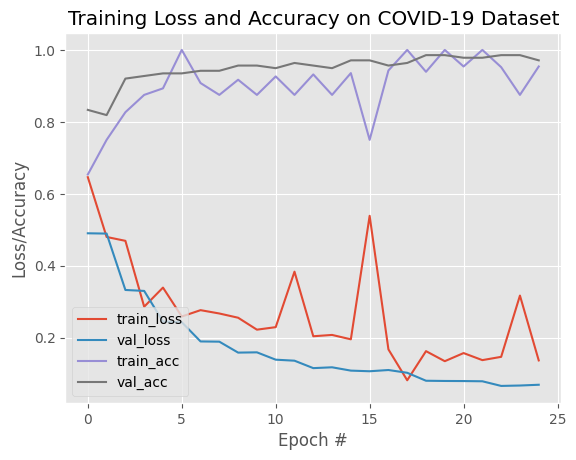

In [ ]:
# plot the training loss and accuracy
N = EPOCHS
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, N), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, N), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, N), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, N), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy on COVID-19 Dataset")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend(loc="lower left")
#plt.savefig(args["plot"])

In [ ]:
predIdxs

array([0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0,
       1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 1, 1, 1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


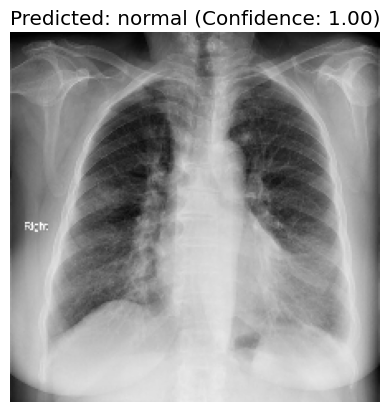

In [ ]:
#from IPython.display import Image
#Image('/content/drive/My Drive/covid dataset/images/1-s2.0-S0929664620300449-gr2_lrg-a.jpg')
image_path = '/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/infected/covid_train (1).jpeg'
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
resized_image = cv2.resize(image, (224, 224))
img=np.reshape(resized_image,(1,224,224,3))

# Make prediction
prediction = model.predict(img)
predicted_class_idx = np.argmax(prediction)
predicted_label = lb.classes_[predicted_class_idx]

# Display image and prediction
plt.imshow(resized_image)
plt.title(f"Predicted: {predicted_label} (Confidence: {prediction[0][predicted_class_idx]:.2f})")
plt.axis('off')
plt.show()

Displaying predictions for 4 images:
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


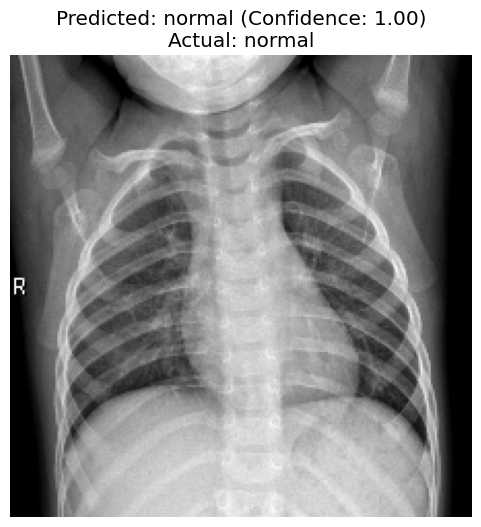

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


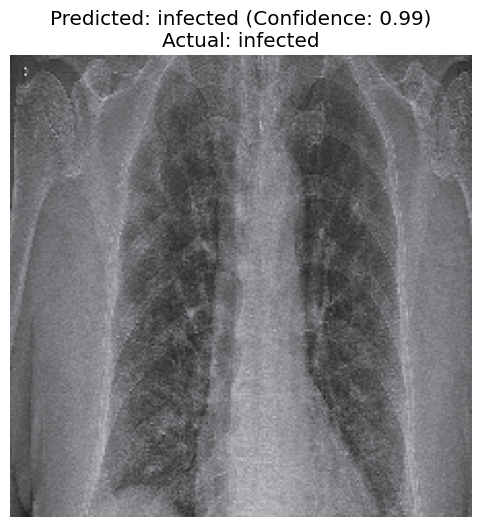

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


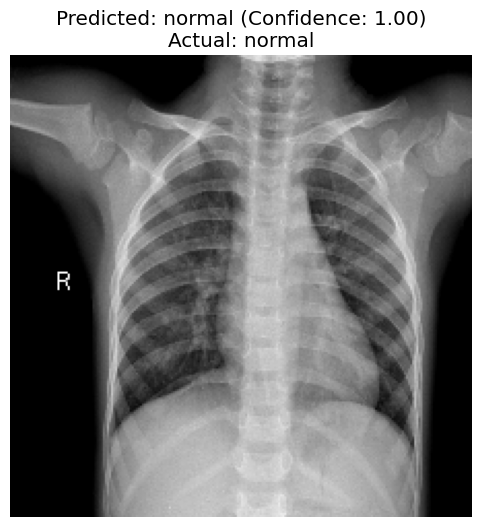

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


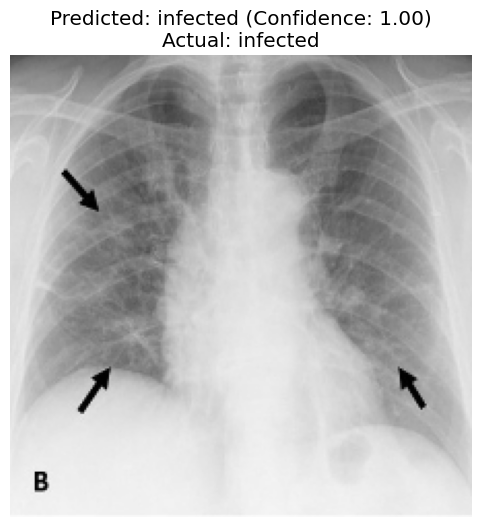

In [ ]:
# Select a few images for visualization (e.g., 2 infected, 2 normal)
num_images_to_display = 4

# Get image paths for infected and normal cases
infected_image_paths = [p for p in imagePaths if 'infected' in p]
normal_image_paths = [p for p in imagePaths if 'normal' in p]

# Randomly select a few images from each class
selected_infected_paths = np.random.choice(infected_image_paths, num_images_to_display // 2, replace=False)
selected_normal_paths = np.random.choice(normal_image_paths, num_images_to_display // 2, replace=False)

# Combine and shuffle the selected paths
selected_image_paths = np.concatenate((selected_infected_paths, selected_normal_paths))
np.random.shuffle(selected_image_paths)

print(f"Displaying predictions for {len(selected_image_paths)} images:")

# Loop through selected image paths and display predictions
for img_path in selected_image_paths:
    image = cv2.imread(img_path)
    if image is None:
        print(f"Warning: Could not load image at {img_path}. Skipping.")
        continue

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    resized_image = cv2.resize(image, (224, 224))
    img_for_prediction = np.reshape(resized_image, (1, 224, 224, 3)) / 255.0 # Scale for model input

    # Make prediction
    prediction = model.predict(img_for_prediction)
    predicted_class_idx = np.argmax(prediction)
    predicted_label = lb.classes_[predicted_class_idx]

    # Display image and prediction
    plt.figure(figsize=(6, 6))
    plt.imshow(resized_image)
    plt.title(f"Predicted: {predicted_label} (Confidence: {prediction[0][predicted_class_idx]:.2f})\nActual: {img_path.split(os.path.sep)[-2]}")
    plt.axis('off')
    plt.show()

In [ ]:
img.shape

(1, 224, 224, 3)

END OF VGG16


WITHOUT PRETRAINED MODEL

In [ ]:
model = Sequential()
model.add(Conv2D(80, (3, 3),activation='relu', input_shape=(224, 224, 3)))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

model.add(Conv2D(32, (3, 3),activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.5))
model.add(Conv2D(32, (3, 3),activation='relu'))


model.add(Conv2D(64, (3, 3),activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))

model.add(Flatten())
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(2,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_chkpt = ModelCheckpoint('best_mod.h5', save_best_only=True, monitor='accuracy')
early_stopping = EarlyStopping(monitor='loss', restore_best_weights=False, patience=10)

In [ ]:
# initialize the initial learning rate, number of epochs to train for,
# and batch size
INIT_LR = 1e-3
EPOCHS = 25
BS = 8
# compile our model
print("[INFO] compiling model...")
opt = Adam(learning_rate=INIT_LR)
model.compile(loss="binary_crossentropy", optimizer=opt,
	metrics=["accuracy"])
# train the head of the network
print("[INFO] training head...")
H = model.fit(
	trainAug.flow(trainX, trainY, batch_size=BS),
	steps_per_epoch=len(trainX) // BS,
	validation_data=(testX, testY),
	validation_steps=len(testX) // BS,
	epochs=EPOCHS,callbacks=[early_stopping,model_chkpt])

[INFO] compiling model...
[INFO] training head...
Epoch 1/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.4995 - loss: 0.7406

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


68/68 ━━━━━━━━━━━━━━━━━━━━ 24s 233ms/step - accuracy: 0.5838 - loss: 0.6821 - val_accuracy: 0.9638 - val_loss: 0.5165
Epoch 2/25
 1/68 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 1.0000 - loss: 0.4078

68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.4078 - val_accuracy: 0.9638 - val_loss: 0.5056
Epoch 3/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 7s 105ms/step - accuracy: 0.8821 - loss: 0.3607 - val_accuracy: 0.9565 - val_loss: 0.2054
Epoch 4/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2500 - loss: 0.7963 - val_accuracy: 0.9638 - val_loss: 0.3454
Epoch 5/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 114ms/step - accuracy: 0.8416 - loss: 0.3430 - val_accuracy: 0.9710 - val_loss: 0.1334
Epoch 6/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0507 - val_accuracy: 0.9710 - val_loss: 0.1275
Epoch 7/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 7s 96ms/step - accuracy: 0.8692 - loss: 0.3201 - val_accuracy: 0.9710 - val_loss: 0.3153
Epoch 8/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.1483 - val_accuracy: 0.9638 - val_loss: 0.2921
Epoch 9/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 12s 178ms/step - accuracy: 0.8877 - loss: 0.2931 - val_accuracy: 0.9493 - val_loss: 0.

In [ ]:
# make predictions on the testing set
print("[INFO] evaluating network...")
predIdxs = model.predict(testX, batch_size=BS)
# for each image in the testing set we need to find the index of the
# label with corresponding largest predicted probability
predIdxs = np.argmax(predIdxs, axis=1)
# show a nicely formatted classification report
print(classification_report(testY.argmax(axis=1), predIdxs,
	target_names=lb.classes_))

[INFO] evaluating network...
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step
              precision    recall  f1-score   support

    infected       0.90      0.97      0.93        64
      normal       0.97      0.91      0.94        74

    accuracy                           0.93       138
   macro avg       0.93      0.94      0.93       138
weighted avg       0.94      0.93      0.93       138



In [ ]:
# compute the confusion matrix and and use it to derive the raw
# accuracy, sensitivity, and specificity
cm = confusion_matrix(testY.argmax(axis=1), predIdxs)
total = sum(sum(cm))
acc = (cm[0, 0] + cm[1, 1]) / total
sensitivity = cm[0, 0] / (cm[0, 0] + cm[0, 1])
specificity = cm[1, 1] / (cm[1, 0] + cm[1, 1])
# show the confusion matrix, accuracy, sensitivity, and specificity
print(cm)
print("acc: {:.4f}".format(acc))
print("sensitivity: {:.4f}".format(sensitivity))
print("specificity: {:.4f}".format(specificity))

[[62  2]
 [ 7 67]]
acc: 0.9348
sensitivity: 0.9688
specificity: 0.9054


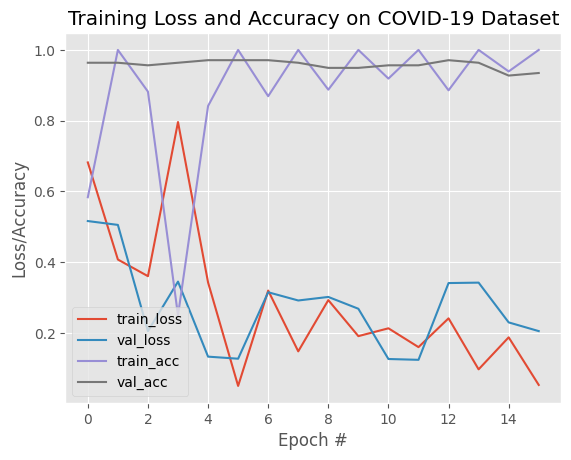

In [ ]:
# plot the training loss and accuracy
N = len(H.history["loss"])
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, N), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, N), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, N), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, N), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy on COVID-19 Dataset")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend(loc="lower left")
#plt.savefig(args["plot"])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 810ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


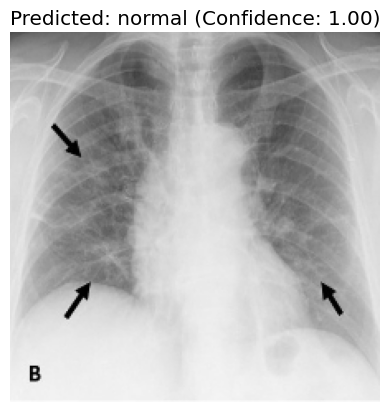

In [ ]:
#from IPython.display import Image
#Image('/content/drive/My Drive/covid dataset/images/1-s2.0-S0929664620300449-gr2_lrg-a.jpg')
image = cv2.imread('/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/infected/covid_train (10).jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = cv2.resize(image, (224, 224))
img=np.reshape(image,(1,224,224,3))
model.predict(img)

# Make prediction
prediction = model.predict(img)
predicted_class_idx = np.argmax(prediction)
predicted_label = lb.classes_[predicted_class_idx]

# Display image and prediction
plt.imshow(resized_image)
plt.title(f"Predicted: {predicted_label} (Confidence: {prediction[0][predicted_class_idx]:.2f})")
plt.axis('off')
plt.show()

END OF WITHOUT PRETRAINED MODEL

USING INCEPTION-V3 MODEL

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16,InceptionV3
from tensorflow.keras.layers import AveragePooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split

In [ ]:
baseModel = InceptionV3(weights="imagenet", include_top=False, input_tensor=Input(shape=(224, 224, 3)))
#construct the head of the model that will be placed on top of the
#the base model

headModel = baseModel.output
headModel = AveragePooling2D(pool_size=(4, 4))(headModel)
headModel = Dropout(0.5)(headModel)
headModel = Flatten(name="flatten")(headModel)
headModel = Dense(64, activation="relu")(headModel)
headModel = Dropout(0.5)(headModel)
headModel = Dense(2, activation="softmax")(headModel)


model= Model(inputs=baseModel.input, outputs=headModel)

for layer in baseModel.layers:
    layer.trainable = False

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [ ]:
model_chkpt = ModelCheckpoint('best_mod.h5', save_best_only=True, monitor='accuracy')
early_stopping = EarlyStopping(monitor='loss', restore_best_weights=False, patience=10)

In [ ]:
# initialize the initial learning rate, number of epochs to train for,
# and batch size
INIT_LR = 1e-3
EPOCHS = 25
BS = 8
# compile our model
print("[INFO] compiling model...")
opt = Adam(learning_rate=INIT_LR)
model.compile(loss="binary_crossentropy", optimizer=opt,
	metrics=["accuracy"])
# train the head of the network
print("[INFO] training head...")
H = model.fit(
	trainAug.flow(trainX, trainY, batch_size=BS),
	steps_per_epoch=len(trainX) // BS,
	validation_data=(testX, testY),
	validation_steps=len(testX) // BS,
	epochs=EPOCHS,callbacks=[early_stopping,model_chkpt])

[INFO] compiling model...
[INFO] training head...
Epoch 1/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.7725 - loss: 0.5430

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


68/68 ━━━━━━━━━━━━━━━━━━━━ 51s 510ms/step - accuracy: 0.8619 - loss: 0.3493 - val_accuracy: 0.9493 - val_loss: 0.1063
Epoch 2/25
 1/68 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 1.0000 - loss: 0.0192

68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 1.0000 - loss: 0.0192 - val_accuracy: 0.9493 - val_loss: 0.1050
Epoch 3/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 119ms/step - accuracy: 0.9116 - loss: 0.2306 - val_accuracy: 0.9855 - val_loss: 0.0714
Epoch 4/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0353 - val_accuracy: 0.9855 - val_loss: 0.0707
Epoch 5/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 7s 104ms/step - accuracy: 0.9374 - loss: 0.1914 - val_accuracy: 0.9783 - val_loss: 0.0619
Epoch 6/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0718 - val_accuracy: 0.9783 - val_loss: 0.0627
Epoch 7/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 122ms/step - accuracy: 0.9540 - loss: 0.1439 - val_accuracy: 0.9710 - val_loss: 0.0841
Epoch 8/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0747 - val_accuracy: 0.9710 - val_loss: 0.0814
Epoch 9/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 124ms/step - accuracy: 0.9521 - loss: 0.1449 - val_accuracy: 0.9855 - val_loss: 

In [ ]:
# make predictions on the testing set
print("[INFO] evaluating network...")
predIdxs = model.predict(testX, batch_size=BS)
# for each image in the testing set we need to find the index of the
# label with corresponding largest predicted probability
predIdxs = np.argmax(predIdxs, axis=1)
# show a nicely formatted classification report
print(classification_report(testY.argmax(axis=1), predIdxs,
	target_names=lb.classes_))

[INFO] evaluating network...
18/18 ━━━━━━━━━━━━━━━━━━━━ 18s 590ms/step
              precision    recall  f1-score   support

    infected       0.98      1.00      0.99        64
      normal       1.00      0.99      0.99        74

    accuracy                           0.99       138
   macro avg       0.99      0.99      0.99       138
weighted avg       0.99      0.99      0.99       138



In [ ]:
# compute the confusion matrix and and use it to derive the raw
# accuracy, sensitivity, and specificity
cm = confusion_matrix(testY.argmax(axis=1), predIdxs)
total = sum(sum(cm))
acc = (cm[0, 0] + cm[1, 1]) / total
sensitivity = cm[0, 0] / (cm[0, 0] + cm[0, 1])
specificity = cm[1, 1] / (cm[1, 0] + cm[1, 1])
# show the confusion matrix, accuracy, sensitivity, and specificity
print(cm)
print("acc: {:.4f}".format(acc))
print("sensitivity: {:.4f}".format(sensitivity))
print("specificity: {:.4f}".format(specificity))

[[64  0]
 [ 1 73]]
acc: 0.9928
sensitivity: 1.0000
specificity: 0.9865


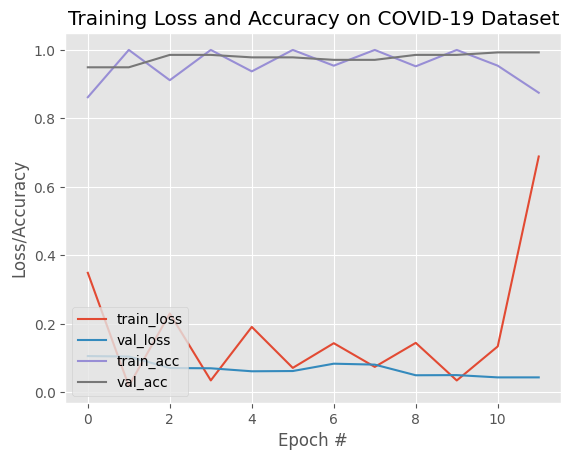

In [ ]:
# plot the training loss and accuracy
N = len(H.history["loss"])
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, N), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, N), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, N), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, N), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy on COVID-19 Dataset")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend(loc="lower left")
#plt.savefig(args["plot"])

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


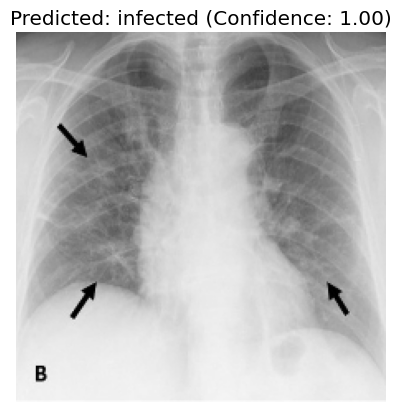

In [ ]:


#from IPython.display import Image
#Image('/content/drive/My Drive/covid dataset/images/1-s2.0-S0929664620300449-gr2_lrg-a.jpg')
image = cv2.imread('/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/infected/covid_train (10).jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = cv2.resize(image, (224, 224))
img=np.reshape(image,(1,224,224,3))
model.predict(img)

# Make prediction
prediction = model.predict(img)
predicted_class_idx = np.argmax(prediction)
predicted_label = lb.classes_[predicted_class_idx]

# Display image and prediction
plt.imshow(resized_image)
plt.title(f"Predicted: {predicted_label} (Confidence: {prediction[0][predicted_class_idx]:.2f})")
plt.axis('off')
plt.show()

END OF INCEPTION V3 MODEL

RESNET50

In [ ]:
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions
import numpy as np

In [ ]:
res = ResNet50(weights="imagenet", include_top=False, input_tensor=Input(shape=(224, 224, 3)))
outputs = res.output
outputs = Flatten(name="flatten")(outputs)
outputs = Dropout(0.5)(outputs)
outputs = Dense(2, activation="softmax")(outputs)
model = Model(inputs=res.input, outputs=outputs)
for layer in res.layers:
  layer.trainable = False


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [ ]:
model_chkpt = ModelCheckpoint('best_mod.h5', save_best_only=True, monitor='accuracy')
early_stopping = EarlyStopping(monitor='loss', restore_best_weights=False, patience=10)

In [ ]:
# initialize the initial learning rate, number of epochs to train for,
# and batch size
INIT_LR = 1e-3
EPOCHS = 25
BS = 8
# compile our model
print("[INFO] compiling model...")
opt = Adam(learning_rate=INIT_LR)
model.compile(loss="binary_crossentropy", optimizer=opt,
	metrics=["accuracy"])
# train the head of the network
print("[INFO] training head...")
H = model.fit(
	trainAug.flow(trainX, trainY, batch_size=BS),
	steps_per_epoch=len(trainX) // BS,
	validation_data=(testX, testY),
	validation_steps=len(testX) // BS,
	epochs=EPOCHS,callbacks=[early_stopping,model_chkpt])

[INFO] compiling model...
[INFO] training head...
Epoch 1/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.5444 - loss: 2.0179

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


68/68 ━━━━━━━━━━━━━━━━━━━━ 36s 347ms/step - accuracy: 0.5709 - loss: 1.4750 - val_accuracy: 0.9348 - val_loss: 0.2294
Epoch 2/25
 1/68 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8750 - loss: 0.3134

68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8750 - loss: 0.3134 - val_accuracy: 0.8043 - val_loss: 0.3278
Epoch 3/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 120ms/step - accuracy: 0.8011 - loss: 0.4871 - val_accuracy: 0.9203 - val_loss: 0.2268
Epoch 4/25
 1/68 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 1.0000 - loss: 0.1451

68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 1.0000 - loss: 0.1451 - val_accuracy: 0.9638 - val_loss: 0.1442
Epoch 5/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 7s 105ms/step - accuracy: 0.8085 - loss: 0.4895 - val_accuracy: 0.9638 - val_loss: 0.1620
Epoch 6/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8750 - loss: 0.2953 - val_accuracy: 0.9638 - val_loss: 0.1793
Epoch 7/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 123ms/step - accuracy: 0.8471 - loss: 0.4005 - val_accuracy: 0.9565 - val_loss: 0.1201
Epoch 8/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8750 - loss: 0.4193 - val_accuracy: 0.9638 - val_loss: 0.1084
Epoch 9/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 119ms/step - accuracy: 0.8122 - loss: 0.5495 - val_accuracy: 0.9638 - val_loss: 0.1552
Epoch 10/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 1.0000 - loss: 0.0309 - val_accuracy: 0.9638 - val_loss: 0.1164
Epoch 11/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 7s 103ms/step - accuracy: 0.7808 - loss: 0.7576 - val_accuracy: 0.9565 - val_loss:

In [ ]:
# make predictions on the testing set
print("[INFO] evaluating network...")
predIdxs = model.predict(testX, batch_size=BS)
# for each image in the testing set we need to find the index of the
# label with corresponding largest predicted probability
predIdxs = np.argmax(predIdxs, axis=1)
# show a nicely formatted classification report
print(classification_report(testY.argmax(axis=1), predIdxs,
	target_names=lb.classes_))

[INFO] evaluating network...
18/18 ━━━━━━━━━━━━━━━━━━━━ 15s 684ms/step
              precision    recall  f1-score   support

    infected       1.00      0.33      0.49        64
      normal       0.63      1.00      0.77        74

    accuracy                           0.69       138
   macro avg       0.82      0.66      0.63       138
weighted avg       0.80      0.69      0.64       138



In [ ]:
# compute the confusion matrix and and use it to derive the raw
# accuracy, sensitivity, and specificity
cm = confusion_matrix(testY.argmax(axis=1), predIdxs)
total = sum(sum(cm))
acc = (cm[0, 0] + cm[1, 1]) / total
sensitivity = cm[0, 0] / (cm[0, 0] + cm[0, 1])
specificity = cm[1, 1] / (cm[1, 0] + cm[1, 1])
# show the confusion matrix, accuracy, sensitivity, and specificity
print(cm)
print("acc: {:.4f}".format(acc))
print("sensitivity: {:.4f}".format(sensitivity))
print("specificity: {:.4f}".format(specificity))

[[21 43]
 [ 0 74]]
acc: 0.6884
sensitivity: 0.3281
specificity: 1.0000


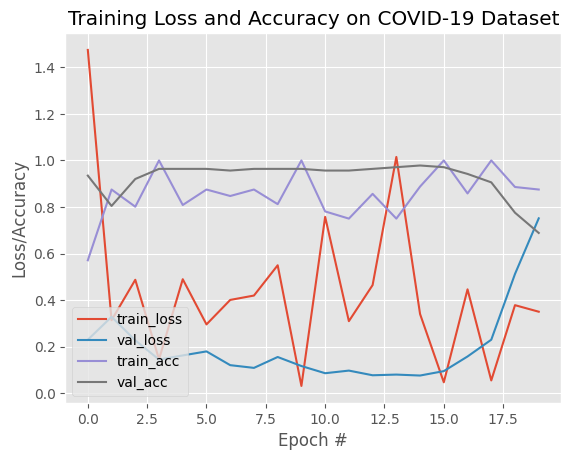

In [ ]:
# plot the training loss and accuracy
N = len(H.history["loss"])
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, N), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, N), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, N), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, N), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy on COVID-19 Dataset")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend(loc="lower left")
#plt.savefig(args["plot"])

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


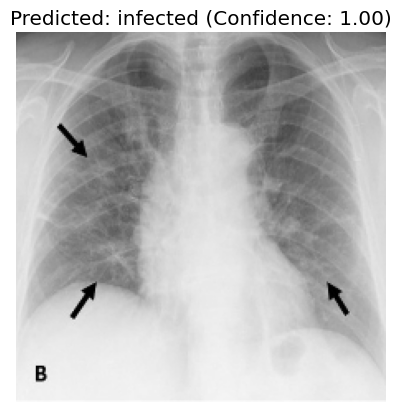

In [ ]:


#from IPython.display import Image
#Image('/content/drive/My Drive/covid dataset/images/1-s2.0-S0929664620300449-gr2_lrg-a.jpg')
image = cv2.imread('/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/infected/covid_train (10).jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = cv2.resize(image, (224, 224))
img=np.reshape(image,(1,224,224,3))
model.predict(img)

# Make prediction
prediction = model.predict(img)
predicted_class_idx = np.argmax(prediction)
predicted_label = lb.classes_[predicted_class_idx]

# Display image and prediction
plt.imshow(resized_image)
plt.title(f"Predicted: {predicted_label} (Confidence: {prediction[0][predicted_class_idx]:.2f})")
plt.axis('off')
plt.show()

END OF RESNET50


MOBILENET BY GOOGLE


In [ ]:
import tensorflow as tf

In [ ]:
IMG_SHAPE = (224,224,3)

# Create the base model from the pre-trained model MobileNet V2
baseModel = tf.keras.applications.MobileNetV2(input_shape=IMG_SHAPE,
                                               include_top=False,
                                               weights='imagenet')
headModel = baseModel.output
headModel = AveragePooling2D(pool_size=(4, 4))(headModel)
headModel = Dropout(0.5)(headModel)
headModel = Flatten(name="flatten")(headModel)
headModel = Dense(64, activation="relu")(headModel)
headModel = Dropout(0.5)(headModel)
headModel = Dense(2, activation="softmax")(headModel)


model= Model(inputs=baseModel.input, outputs=headModel)

for layer in baseModel.layers:
    layer.trainable = False


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
model_chkpt = ModelCheckpoint('best_mod.h5', save_best_only=True, monitor='accuracy')
early_stopping = EarlyStopping(monitor='loss', restore_best_weights=False, patience=10)

In [ ]:
# initialize the initial learning rate, number of epochs to train for,
# and batch size
INIT_LR = 1e-3
EPOCHS = 25
BS = 8
# compile our model
print("[INFO] compiling model...")
opt = Adam(learning_rate=INIT_LR)
model.compile(loss="binary_crossentropy", optimizer=opt,
	metrics=["accuracy"])
# train the head of the network
print("[INFO] training head...")
H = model.fit(
	trainAug.flow(trainX, trainY, batch_size=BS),
	steps_per_epoch=len(trainX) // BS,
	validation_data=(testX, testY),
	validation_steps=len(testX) // BS,
	epochs=EPOCHS,callbacks=[early_stopping,model_chkpt])

[INFO] compiling model...
[INFO] training head...
Epoch 1/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 0.6792 - loss: 0.7658

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


68/68 ━━━━━━━━━━━━━━━━━━━━ 72s 717ms/step - accuracy: 0.8048 - loss: 0.4934 - val_accuracy: 0.9565 - val_loss: 0.1218
Epoch 2/25
 1/68 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8750 - loss: 0.2054

68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8750 - loss: 0.2054 - val_accuracy: 0.9710 - val_loss: 0.1169
Epoch 3/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.8904 - loss: 0.2559

68/68 ━━━━━━━━━━━━━━━━━━━━ 7s 108ms/step - accuracy: 0.9006 - loss: 0.2414 - val_accuracy: 0.9783 - val_loss: 0.0784
Epoch 4/25
 1/68 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 1.0000 - loss: 0.0401

68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 1.0000 - loss: 0.0401 - val_accuracy: 0.9783 - val_loss: 0.0781
Epoch 5/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - accuracy: 0.9319 - loss: 0.2015 - val_accuracy: 0.9710 - val_loss: 0.0801
Epoch 6/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0400 - val_accuracy: 0.9783 - val_loss: 0.0767
Epoch 7/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 115ms/step - accuracy: 0.9521 - loss: 0.1418 - val_accuracy: 0.9928 - val_loss: 0.0555
Epoch 8/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0711 - val_accuracy: 0.9928 - val_loss: 0.0552
Epoch 9/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - accuracy: 0.9521 - loss: 0.1352 - val_accuracy: 0.9855 - val_loss: 0.0466
Epoch 10/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8750 - loss: 0.1171 - val_accuracy: 0.9855 - val_loss: 0.0479
Epoch 11/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 112ms/step - accuracy: 0.9521 - loss: 0.1308 - val_accuracy: 0.9855 - val_loss: 0

In [ ]:
# make predictions on the testing set
print("[INFO] evaluating network...")
predIdxs = model.predict(testX, batch_size=BS)
# for each image in the testing set we need to find the index of the
# label with corresponding largest predicted probability
predIdxs = np.argmax(predIdxs, axis=1)
# show a nicely formatted classification report
print(classification_report(testY.argmax(axis=1), predIdxs,
	target_names=lb.classes_))

[INFO] evaluating network...
18/18 ━━━━━━━━━━━━━━━━━━━━ 19s 824ms/step
              precision    recall  f1-score   support

    infected       0.98      0.95      0.97        64
      normal       0.96      0.99      0.97        74

    accuracy                           0.97       138
   macro avg       0.97      0.97      0.97       138
weighted avg       0.97      0.97      0.97       138



In [ ]:
# compute the confusion matrix and and use it to derive the raw
# accuracy, sensitivity, and specificity
cm = confusion_matrix(testY.argmax(axis=1), predIdxs)
total = sum(sum(cm))
acc = (cm[0, 0] + cm[1, 1]) / total
sensitivity = cm[0, 0] / (cm[0, 0] + cm[0, 1])
specificity = cm[1, 1] / (cm[1, 0] + cm[1, 1])
# show the confusion matrix, accuracy, sensitivity, and specificity
print(cm)
print("acc: {:.4f}".format(acc))
print("sensitivity: {:.4f}".format(sensitivity))
print("specificity: {:.4f}".format(specificity))

[[61  3]
 [ 1 73]]
acc: 0.9710
sensitivity: 0.9531
specificity: 0.9865


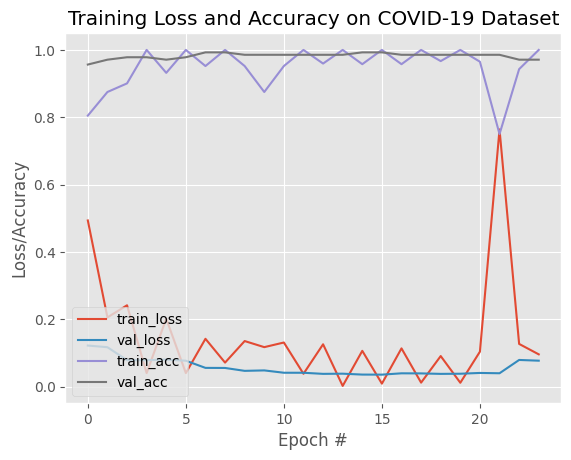

In [ ]:
# plot the training loss and accuracy
N = len(H.history["loss"])
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, N), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, N), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, N), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, N), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy on COVID-19 Dataset")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend(loc="lower left")
#plt.savefig(args["plot"])

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


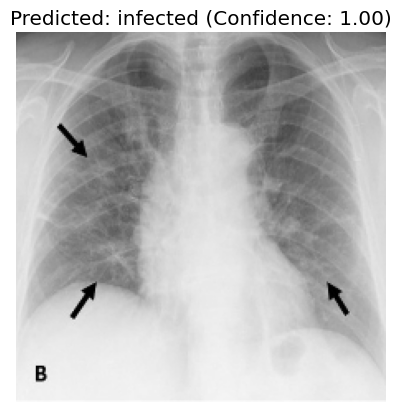

In [ ]:


#from IPython.display import Image
#Image('/content/drive/My Drive/covid dataset/images/1-s2.0-S0929664620300449-gr2_lrg-a.jpg')
image = cv2.imread('/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/infected/covid_train (10).jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = cv2.resize(image, (224, 224))
img=np.reshape(image,(1,224,224,3))
model.predict(img)

# Make prediction
prediction = model.predict(img)
predicted_class_idx = np.argmax(prediction)
predicted_label = lb.classes_[predicted_class_idx]

# Display image and prediction
plt.imshow(resized_image)
plt.title(f"Predicted: {predicted_label} (Confidence: {prediction[0][predicted_class_idx]:.2f})")
plt.axis('off')
plt.show()

END OF MOBILENET


NASNetlarge

In [ ]:
from tensorflow.keras.applications.nasnet import NASNetLarge


In [ ]:
IMG_SHAPE = (224,224,3)

# Create the base model from the pre-trained model MobileNet V2
baseModel = tf.keras.applications.NASNetLarge(include_top=False,weights='imagenet',input_tensor=Input(shape=(224, 224, 3)))
headModel = baseModel.output
headModel = AveragePooling2D(pool_size=(4, 4))(headModel)
headModel = Dropout(0.5)(headModel)
headModel = Flatten(name="flatten")(headModel)
headModel = Dense(64, activation="relu")(headModel)
headModel = Dropout(0.5)(headModel)
headModel = Dense(2, activation="softmax")(headModel)


model= Model(inputs=baseModel.input, outputs=headModel)

for layer in baseModel.layers:
    layer.trainable = False


343610240/343610240 ━━━━━━━━━━━━━━━━━━━━ 22s 0us/step


In [ ]:
# initialize the initial learning rate, number of epochs to train for,
# and batch size
INIT_LR = 1e-3
EPOCHS = 25
BS = 8
# compile our model
print("[INFO] compiling model...")
opt = Adam(learning_rate=INIT_LR)
model.compile(loss="binary_crossentropy", optimizer=opt,
	metrics=["accuracy"])
# train the head of the network
print("[INFO] training head...")
H = model.fit(
	trainAug.flow(trainX, trainY, batch_size=BS),
	steps_per_epoch=len(trainX) // BS,
	validation_data=(testX, testY),
	validation_steps=len(testX) // BS,
	epochs=EPOCHS,callbacks=[early_stopping,model_chkpt])

[INFO] compiling model...
[INFO] training head...
Epoch 1/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 186s 2s/step - accuracy: 0.8895 - loss: 0.3416 - val_accuracy: 0.9493 - val_loss: 0.2129
Epoch 2/25


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 0.9565 - val_loss: 0.2141
Epoch 3/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 12s 173ms/step - accuracy: 0.9392 - loss: 0.1624 - val_accuracy: 0.9710 - val_loss: 0.0978
Epoch 4/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 1.0000 - loss: 0.1111 - val_accuracy: 0.9710 - val_loss: 0.0986
Epoch 5/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 19s 177ms/step - accuracy: 0.9503 - loss: 0.1253 - val_accuracy: 0.9710 - val_loss: 0.1232
Epoch 6/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 1.0000 - loss: 0.1218 - val_accuracy: 0.9710 - val_loss: 0.1158
Epoch 7/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 12s 175ms/step - accuracy: 0.9669 - loss: 0.1181 - val_accuracy: 0.9855 - val_loss: 0.1125
Epoch 8/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 1.0000 - loss: 0.0068 - val_accuracy: 0.9855 - val_loss: 0.1156
Epoch 9/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 12s 168ms/step - accuracy: 0.9705 - loss: 0.0988 - val_accuracy: 0.9783 - val_

[INFO] evaluating network...
18/18 ━━━━━━━━━━━━━━━━━━━━ 87s 3s/step
              precision    recall  f1-score   support

    infected       0.98      0.97      0.98        64
      normal       0.97      0.99      0.98        74

    accuracy                           0.98       138
   macro avg       0.98      0.98      0.98       138
weighted avg       0.98      0.98      0.98       138

[[62  2]
 [ 1 73]]
acc: 0.9783
sensitivity: 0.9688
specificity: 0.9865


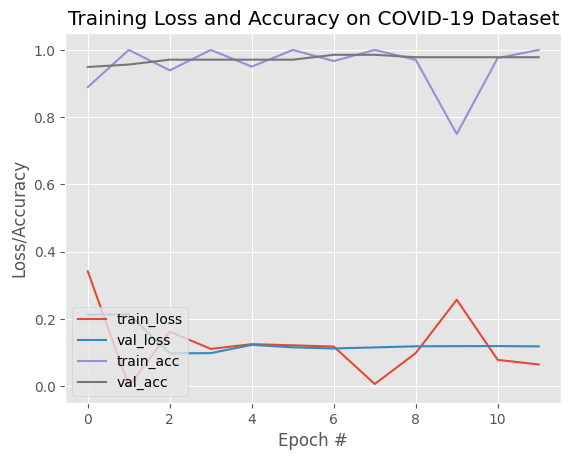

In [ ]:
# make predictions on the testing set
print("[INFO] evaluating network...")
predIdxs = model.predict(testX, batch_size=BS)
# for each image in the testing set we need to find the index of the
# label with corresponding largest predicted probability
predIdxs = np.argmax(predIdxs, axis=1)
# show a nicely formatted classification report
print(classification_report(testY.argmax(axis=1), predIdxs,
	target_names=lb.classes_))



  # compute the confusion matrix and and use it to derive the raw
# accuracy, sensitivity, and specificity
cm = confusion_matrix(testY.argmax(axis=1), predIdxs)
total = sum(sum(cm))
acc = (cm[0, 0] + cm[1, 1]) / total
sensitivity = cm[0, 0] / (cm[0, 0] + cm[0, 1])
specificity = cm[1, 1] / (cm[1, 0] + cm[1, 1])
# show the confusion matrix, accuracy, sensitivity, and specificity
print(cm)
print("acc: {:.4f}".format(acc))
print("sensitivity: {:.4f}".format(sensitivity))
print("specificity: {:.4f}".format(specificity))


# plot the training loss and accuracy
N = len(H.history["loss"])
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, N), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, N), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, N), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, N), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy on COVID-19 Dataset")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend(loc="lower left")
#plt.savefig(args["plot"])

1/1 ━━━━━━━━━━━━━━━━━━━━ 36s 36s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step


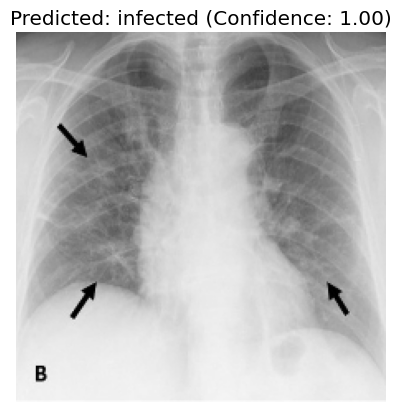

In [ ]:

#from IPython.display import Image
#Image('/content/drive/My Drive/covid dataset/images/1-s2.0-S0929664620300449-gr2_lrg-a.jpg')
image = cv2.imread('/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/infected/covid_train (10).jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = cv2.resize(image, (224, 224))
img=np.reshape(image,(1,224,224,3))
model.predict(img)

# Make prediction
prediction = model.predict(img)
predicted_class_idx = np.argmax(prediction)
predicted_label = lb.classes_[predicted_class_idx]

# Display image and prediction
plt.imshow(resized_image)
plt.title(f"Predicted: {predicted_label} (Confidence: {prediction[0][predicted_class_idx]:.2f})")
plt.axis('off')
plt.show()

END OF NASNetLarge


Xception MODEL

### Re-initializing Data Augmentation and Splits

This cell re-defines the `trainAug` object and re-creates the training and testing data splits (`trainX`, `trainY`, `testX`, `testY`) and `LabelBinarizer` (`lb`). This is necessary to ensure these variables are available and correctly configured for the models that follow, especially after potential kernel restarts or out-of-order execution that might clear their definitions.

In [ ]:
import os
import numpy as np
import cv2 # Assuming cv2 is needed for image processing based on earlier cells
from sklearn.preprocessing import LabelBinarizer
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# Re-define DIR_NAME and collect image paths
DIR_NAME = '/content/Classification-of-COVID-19-chest-X-ray-images/dataset/'
imagePaths=[]
for dirname, _, filenames in os.walk(DIR_NAME):
    for filename in filenames:
      imagePaths.append(os.path.join(dirname, filename))

# Load and preprocess images, create data and labels arrays
data = []
labels = []
# loop over the image paths
for imagePath in imagePaths:
	# extract the class label from the filename
	label = imagePath.split(os.path.sep)[-2]
	# load the image, swap color channels, and resize it to be a fixed
	# 224x224 pixels while ignoring aspect ratio
	image = cv2.imread(imagePath)
	if image is None: # Added error handling for images that might fail to load
		print(f"Warning: Could not load image at {imagePath}. Skipping.")
		continue
	image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
	image = cv2.resize(image, (224, 224))
	# update the data and labels lists, respectively
	data.append(image)
	labels.append(label)
# convert the data and labels to NumPy arrays while scaling the pixel
# intensities to the range [0, 1]
data = np.array(data) / 255.0
labels = np.array(labels)

# perform one-hot encoding on the labels
lb = LabelBinarizer()
labels = lb.fit_transform(labels)
labels = to_categorical(labels)
# partition the data into training and testing splits using 80% of
# the data for training and the remaining 20% for testing
(trainX, testX, trainY, testY) = train_test_split(data, labels,
	test_size=0.20, stratify=labels, random_state=42)
# initialize the training data augmentation object
trainAug = ImageDataGenerator(shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,	rotation_range=15,
	fill_mode="nearest")

In [ ]:
from tensorflow.keras.applications.xception import Xception
from tensorflow.keras.preprocessing import image
#from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions
import numpy as np

In [ ]:
import tensorflow as tf

IMG_SHAPE = (224,224,3)

# Create the base model from the pre-trained model Xception
baseModel = tf.keras.applications.Xception(include_top=False,weights='imagenet',input_tensor=tf.keras.layers.Input(shape=(224, 224, 3)))
headModel = baseModel.output
headModel = tf.keras.layers.AveragePooling2D(pool_size=(4, 4))(headModel)
headModel = tf.keras.layers.Dropout(0.5)(headModel)
headModel = tf.keras.layers.Flatten(name="flatten")(headModel)
headModel = tf.keras.layers.Dense(64, activation="relu")(headModel)
headModel = tf.keras.layers.Dropout(0.5)(headModel)
headModel = tf.keras.layers.Dense(2, activation="softmax")(headModel)


Xception_model= tf.keras.models.Model(inputs=baseModel.input, outputs=headModel)

for layer in baseModel.layers:
    layer.trainable = False

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.optimizers import Adam

model_chkpt = ModelCheckpoint('best_mod.h5', save_best_only=True, monitor='accuracy')
early_stopping = EarlyStopping(monitor='loss', restore_best_weights=False, patience=10)

# initialize the initial learning rate, number of epochs to train for,
# and batch size
INIT_LR = 1e-3
EPOCHS = 25
BS = 8
# compile our model
print("[INFO] compiling model...")
opt = Adam(learning_rate=INIT_LR)
Xception_model.compile(loss="binary_crossentropy", optimizer=opt,
	metrics=["accuracy"])
# train the head of the network
print("[INFO] training head...")
H = Xception_model.fit(
	trainAug.flow(trainX, trainY, batch_size=BS),
	steps_per_epoch=len(trainX) // BS,
	validation_data=(testX, testY),
	validation_steps=len(testX) // BS,
	epochs=EPOCHS,callbacks=[early_stopping,model_chkpt])

[INFO] compiling model...
[INFO] training head...
Epoch 1/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - accuracy: 0.8595 - loss: 0.3321

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


68/68 ━━━━━━━━━━━━━━━━━━━━ 74s 752ms/step - accuracy: 0.9153 - loss: 0.2240 - val_accuracy: 0.9710 - val_loss: 0.0701
Epoch 2/25
 1/68 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 1.0000 - loss: 0.0548

68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 1.0000 - loss: 0.0548 - val_accuracy: 0.9710 - val_loss: 0.0701
Epoch 3/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 114ms/step - accuracy: 0.9687 - loss: 0.1084 - val_accuracy: 0.9855 - val_loss: 0.0630
Epoch 4/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 1.0000 - loss: 0.0989 - val_accuracy: 0.9855 - val_loss: 0.0643
Epoch 5/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 111ms/step - accuracy: 0.9595 - loss: 0.1115 - val_accuracy: 0.9855 - val_loss: 0.0353
Epoch 6/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 1.0000 - loss: 0.0352 - val_accuracy: 0.9855 - val_loss: 0.0355
Epoch 7/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 127ms/step - accuracy: 0.9816 - loss: 0.0814 - val_accuracy: 0.9855 - val_loss: 0.0524
Epoch 8/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8750 - loss: 0.1456 - val_accuracy: 0.9855 - val_loss: 0.0523
Epoch 9/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 125ms/step - accuracy: 0.9705 - loss: 0.0762 - val_accuracy: 0.9855 - val_loss

[INFO] evaluating network...
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step
              precision    recall  f1-score   support

    infected       1.00      0.97      0.98        64
      normal       0.97      1.00      0.99        74

    accuracy                           0.99       138
   macro avg       0.99      0.98      0.99       138
weighted avg       0.99      0.99      0.99       138

[[62  2]
 [ 0 74]]
acc: 0.9855
sensitivity: 0.9688
specificity: 1.0000


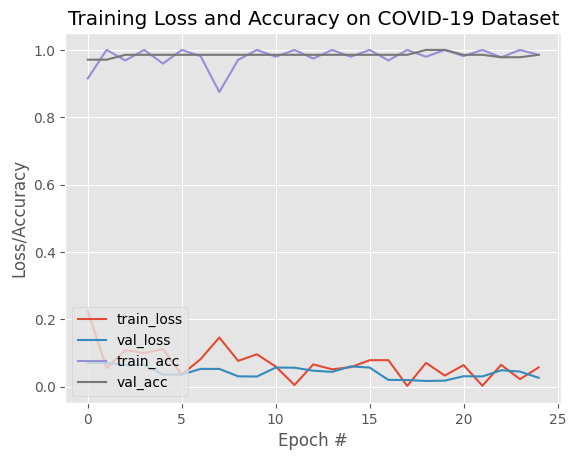

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# make predictions on the testing set
print("[INFO] evaluating network...")
predIdxs = Xception_model.predict(testX, batch_size=BS)
# for each image in the testing set we need to find the index of the
# label with corresponding largest predicted probability
predIdxs = np.argmax(predIdxs, axis=1)
# show a nicely formatted classification report
print(classification_report(testY.argmax(axis=1), predIdxs,
	target_names=lb.classes_))



  # compute the confusion matrix and and use it to derive the raw
# accuracy, sensitivity, and specificity
cm = confusion_matrix(testY.argmax(axis=1), predIdxs)
total = sum(sum(cm))
acc = (cm[0, 0] + cm[1, 1]) / total
sensitivity = cm[0, 0] / (cm[0, 0] + cm[0, 1])
specificity = cm[1, 1] / (cm[1, 0] + cm[1, 1])
# show the confusion matrix, accuracy, sensitivity, and specificity
print(cm)
print("acc: {:.4f}".format(acc))
print("sensitivity: {:.4f}".format(sensitivity))
print("specificity: {:.4f}".format(specificity))


# plot the training loss and accuracy
N = len(H.history["loss"])
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, N), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, N), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, N), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, N), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy on COVID-19 Dataset")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend(loc="lower left")
#plt.savefig(args["plot"])

1/1 ━━━━━━━━━━━━━━━━━━━━ 17s 17s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


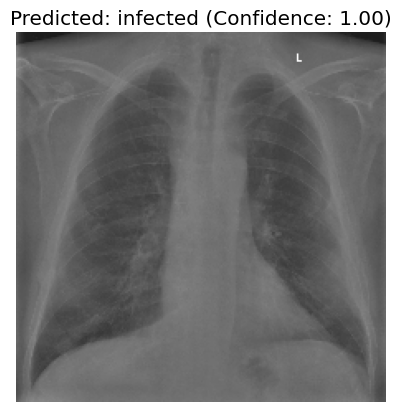

In [ ]:
image = cv2.imread('/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/infected/covid_train (10).jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = cv2.resize(image, (224, 224))
img=np.reshape(image,(1,224,224,3))
Xception_model.predict(img)

# Make prediction
prediction = Xception_model.predict(img)
predicted_class_idx = np.argmax(prediction)
predicted_label = lb.classes_[predicted_class_idx]

# Display image and prediction
plt.imshow(image)
plt.title(f"Predicted: {predicted_label} (Confidence: {prediction[0][predicted_class_idx]:.2f})")
plt.axis('off')
plt.show()

END OF XCEPTION

DENSENET121

In [ ]:
from tensorflow.keras.applications import DenseNet121


In [ ]:
IMG_SHAPE = (224,224,3)

# Create the base model from the pre-trained model MobileNet V2
baseModel = tf.keras.applications.DenseNet121(include_top=False,weights='imagenet',input_tensor=tf.keras.layers.Input(shape=(224, 224, 3)))
headModel = baseModel.output
headModel = tf.keras.layers.AveragePooling2D(pool_size=(4, 4))(headModel)
headModel = tf.keras.layers.Dropout(0.5)(headModel)
headModel = tf.keras.layers.Flatten(name="flatten")(headModel)
headModel = tf.keras.layers.Dense(64, activation="relu")(headModel)
headModel = tf.keras.layers.Dropout(0.5)(headModel)
headModel = tf.keras.layers.Dense(2, activation="softmax")(headModel)


DenseNet121_model= tf.keras.models.Model(inputs=baseModel.input, outputs=headModel)

for layer in baseModel.layers:
    layer.trainable = False

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import AveragePooling2D, Dropout, Flatten, Dense, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

IMG_SHAPE = (224,224,3)

# Create the base model from the pre-trained model DenseNet121
baseModel = tf.keras.applications.DenseNet121(include_top=False,weights='imagenet',input_tensor=Input(shape=(224, 224, 3)))
headModel = baseModel.output
headModel = AveragePooling2D(pool_size=(4, 4))(headModel)
headModel = Dropout(0.5)(headModel)
headModel = Flatten(name="flatten")(headModel)
headModel = Dense(64, activation="relu")(headModel)
headModel = Dropout(0.5)(headModel)
headModel = Dense(2, activation="softmax")(headModel)


DenseNet121_model= Model(inputs=baseModel.input, outputs=headModel)

for layer in baseModel.layers:
    layer.trainable = False

model_chkpt = ModelCheckpoint('best_mod.h5', save_best_only=True, monitor='accuracy')
early_stopping = EarlyStopping(monitor='loss', restore_best_weights=False, patience=10)

# initialize the initial learning rate, number of epochs to train for,
# and batch size
INIT_LR = 1e-3
EPOCHS = 25
BS = 8
# compile our model
print("[INFO] compiling model...")
opt = Adam(learning_rate=INIT_LR)
DenseNet121_model.compile(loss="binary_crossentropy", optimizer=opt,
	metrics=["accuracy"])
# train the head of the network
print("[INFO] training head...")
H = DenseNet121_model.fit(
	trainAug.flow(trainX, trainY, batch_size=BS),
	steps_per_epoch=len(trainX) // BS,
	validation_data=(testX, testY),
	validation_steps=len(testX) // BS,
	epochs=EPOCHS,callbacks=[early_stopping,model_chkpt])

[INFO] compiling model...
[INFO] training head...
Epoch 1/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 0.6277 - loss: 0.7887

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


68/68 ━━━━━━━━━━━━━━━━━━━━ 82s 777ms/step - accuracy: 0.7643 - loss: 0.5626 - val_accuracy: 0.9348 - val_loss: 0.1693
Epoch 2/25
 1/68 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.8750 - loss: 0.2417

68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8750 - loss: 0.2417 - val_accuracy: 0.9348 - val_loss: 0.1668
Epoch 3/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.8728 - loss: 0.3088

68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 144ms/step - accuracy: 0.8877 - loss: 0.2882 - val_accuracy: 0.9493 - val_loss: 0.1319
Epoch 4/25
 1/68 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 1.0000 - loss: 0.1676

68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 1.0000 - loss: 0.1676 - val_accuracy: 0.9565 - val_loss: 0.1286
Epoch 5/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 123ms/step - accuracy: 0.8950 - loss: 0.2405 - val_accuracy: 0.9783 - val_loss: 0.1007
Epoch 6/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8750 - loss: 0.1778 - val_accuracy: 0.9783 - val_loss: 0.1000
Epoch 7/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 124ms/step - accuracy: 0.9300 - loss: 0.2048 - val_accuracy: 0.9783 - val_loss: 0.0934
Epoch 8/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 1.0000 - loss: 0.0952 - val_accuracy: 0.9783 - val_loss: 0.0937
Epoch 9/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 106ms/step - accuracy: 0.9098 - loss: 0.2156 - val_accuracy: 0.9783 - val_loss: 0.0832
Epoch 10/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8750 - loss: 0.6463 - val_accuracy: 0.9783 - val_loss: 0.0823
Epoch 11/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 122ms/step - accuracy: 0.9355 - loss: 0.1858 - val_accuracy: 0.9783 - val_loss

[INFO] evaluating network...
18/18 ━━━━━━━━━━━━━━━━━━━━ 30s 930ms/step
              precision    recall  f1-score   support

    infected       0.98      0.97      0.98        64
      normal       0.97      0.99      0.98        74

    accuracy                           0.98       138
   macro avg       0.98      0.98      0.98       138
weighted avg       0.98      0.98      0.98       138

[[62  2]
 [ 1 73]]
acc: 0.9783
sensitivity: 0.9688
specificity: 0.9865


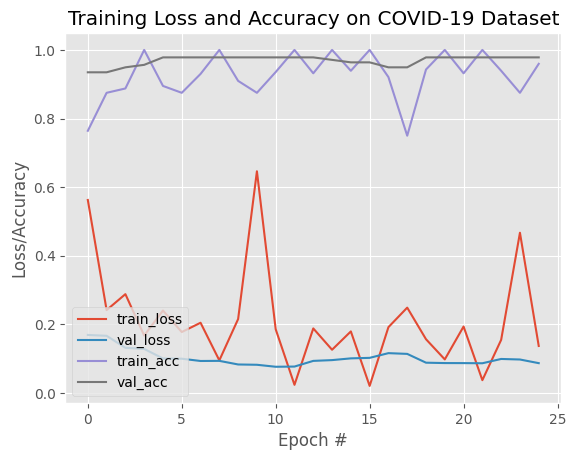

In [ ]:
# make predictions on the testing set
print("[INFO] evaluating network...")
predIdxs = DenseNet121_model.predict(testX, batch_size=BS)
# for each image in the testing set we need to find the index of the
# label with corresponding largest predicted probability
predIdxs = np.argmax(predIdxs, axis=1)
# show a nicely formatted classification report
print(classification_report(testY.argmax(axis=1), predIdxs,
	target_names=lb.classes_))



  # compute the confusion matrix and and use it to derive the raw
# accuracy, sensitivity, and specificity
cm = confusion_matrix(testY.argmax(axis=1), predIdxs)
total = sum(sum(cm))
acc = (cm[0, 0] + cm[1, 1]) / total
sensitivity = cm[0, 0] / (cm[0, 0] + cm[0, 1])
specificity = cm[1, 1] / (cm[1, 0] + cm[1, 1])
# show the confusion matrix, accuracy, sensitivity, and specificity
print(cm)
print("acc: {:.4f}".format(acc))
print("sensitivity: {:.4f}".format(sensitivity))
print("specificity: {:.4f}".format(specificity))


# plot the training loss and accuracy
N = len(H.history["loss"])
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, N), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, N), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, N), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, N), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy on COVID-19 Dataset")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend(loc="lower left")
#plt.savefig(args["plot"])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step


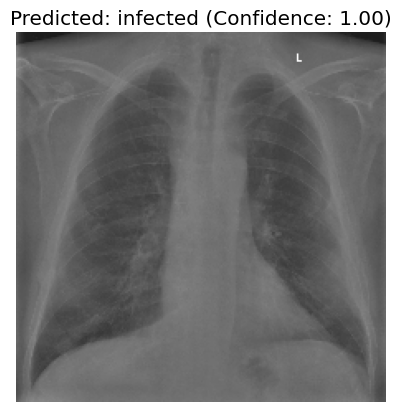

In [ ]:
image = cv2.imread('/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/infected/covid_train (10).jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = cv2.resize(image, (224, 224))
img=np.reshape(image,(1,224,224,3))
DenseNet121_model.predict(img)

# Make prediction
prediction = DenseNet121_model.predict(img)
predicted_class_idx = np.argmax(prediction)
predicted_label = lb.classes_[predicted_class_idx]

# Display image and prediction
plt.imshow(image)
plt.title(f"Predicted: {predicted_label} (Confidence: {prediction[0][predicted_class_idx]:.2f})")
plt.axis('off')
plt.show()

END OF DENSE121


INCEPTION RESNETV2

In [ ]:
from tensorflow.keras.applications.inception_resnet_v2 import InceptionResNetV2, preprocess_input

In [ ]:
IMG_SHAPE = (224,224,3)

# Create the base model from the pre-trained model Xception
baseModel = InceptionResNetV2(include_top=False,weights='imagenet',input_tensor=Input(shape=(224, 224, 3)))
headModel = baseModel.output
headModel = AveragePooling2D(pool_size=(4, 4))(headModel)
headModel = Dropout(0.5)(headModel)
headModel = Flatten(name="flatten")(headModel)
headModel = Dense(64, activation="relu")(headModel)
headModel = Dropout(0.5)(headModel)
headModel = Dense(2, activation="softmax")(headModel)


InceptionResNetV2_model= Model(inputs=baseModel.input, outputs=headModel)

for layer in baseModel.layers:
    layer.trainable = False

219055592/219055592 ━━━━━━━━━━━━━━━━━━━━ 10s 0us/step


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications.inception_resnet_v2 import InceptionResNetV2
from tensorflow.keras.layers import AveragePooling2D, Dropout, Flatten, Dense, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

IMG_SHAPE = (224,224,3)

# Create the base model from the pre-trained model InceptionResNetV2
baseModel = InceptionResNetV2(include_top=False,weights='imagenet',input_tensor=Input(shape=(224, 224, 3)))
headModel = baseModel.output
headModel = AveragePooling2D(pool_size=(4, 4))(headModel)
headModel = Dropout(0.5)(headModel)
headModel = Flatten(name="flatten")(headModel)
headModel = Dense(64, activation="relu")(headModel)
headModel = Dropout(0.5)(headModel)
headModel = Dense(2, activation="softmax")(headModel)


InceptionResNetV2_model= Model(inputs=baseModel.input, outputs=headModel)

for layer in baseModel.layers:
    layer.trainable = False

model_chkpt = ModelCheckpoint('best_mod.h5', save_best_only=True, monitor='accuracy')
early_stopping = EarlyStopping(monitor='loss', restore_best_weights=False, patience=10)
# initialize the initial learning rate, number of epochs to train for,
# and batch size
INIT_LR = 1e-3
EPOCHS = 25
BS = 8
# compile our model
print("[INFO] compiling model...")
opt = Adam(learning_rate=INIT_LR)
InceptionResNetV2_model.compile(loss="binary_crossentropy", optimizer=opt,
	metrics=["accuracy"])
# train the head of the network
print("[INFO] training head...")
H = InceptionResNetV2_model.fit(
	trainAug.flow(trainX, trainY, batch_size=BS),
	steps_per_epoch=len(trainX) // BS,
	validation_data=(testX, testY),
	validation_steps=len(testX) // BS,
	epochs=EPOCHS,callbacks=[early_stopping,model_chkpt])

[INFO] compiling model...
[INFO] training head...
Epoch 1/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - accuracy: 0.7290 - loss: 0.7050

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


68/68 ━━━━━━━━━━━━━━━━━━━━ 83s 690ms/step - accuracy: 0.8232 - loss: 0.4664 - val_accuracy: 0.9710 - val_loss: 0.1014
Epoch 2/25
 1/68 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - accuracy: 1.0000 - loss: 0.1230

68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - accuracy: 1.0000 - loss: 0.1230 - val_accuracy: 0.9710 - val_loss: 0.1021
Epoch 3/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 132ms/step - accuracy: 0.9171 - loss: 0.2217 - val_accuracy: 0.9638 - val_loss: 0.1048
Epoch 4/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 1.0000 - loss: 0.1248 - val_accuracy: 0.9638 - val_loss: 0.1011
Epoch 5/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 120ms/step - accuracy: 0.9227 - loss: 0.2057 - val_accuracy: 0.9638 - val_loss: 0.0842
Epoch 6/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8750 - loss: 0.1975 - val_accuracy: 0.9783 - val_loss: 0.0796
Epoch 7/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 129ms/step - accuracy: 0.9503 - loss: 0.1610 - val_accuracy: 0.9783 - val_loss: 0.0577
Epoch 8/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 1.0000 - loss: 0.0169 - val_accuracy: 0.9710 - val_loss: 0.0630
Epoch 9/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 143ms/step - accuracy: 0.9448 - loss: 0.1496 - val_accuracy: 0.9855 - val_lo

[INFO] evaluating network...
18/18 ━━━━━━━━━━━━━━━━━━━━ 29s 945ms/step
              precision    recall  f1-score   support

    infected       0.98      1.00      0.99        64
      normal       1.00      0.99      0.99        74

    accuracy                           0.99       138
   macro avg       0.99      0.99      0.99       138
weighted avg       0.99      0.99      0.99       138

[[64  0]
 [ 1 73]]
acc: 0.9928
sensitivity: 1.0000
specificity: 0.9865


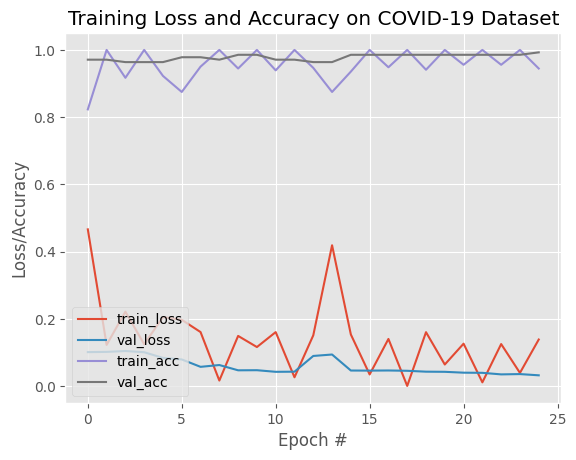

In [ ]:
# make predictions on the testing set
print("[INFO] evaluating network...")
predIdxs = InceptionResNetV2_model.predict(testX, batch_size=BS)
# for each image in the testing set we need to find the index of the
# label with corresponding largest predicted probability
predIdxs = np.argmax(predIdxs, axis=1)
# show a nicely formatted classification report
print(classification_report(testY.argmax(axis=1), predIdxs,
	target_names=lb.classes_))



  # compute the confusion matrix and and use it to derive the raw
# accuracy, sensitivity, and specificity
cm = confusion_matrix(testY.argmax(axis=1), predIdxs)
total = sum(sum(cm))
acc = (cm[0, 0] + cm[1, 1]) / total
sensitivity = cm[0, 0] / (cm[0, 0] + cm[0, 1])
specificity = cm[1, 1] / (cm[1, 0] + cm[1, 1])
# show the confusion matrix, accuracy, sensitivity, and specificity
print(cm)
print("acc: {:.4f}".format(acc))
print("sensitivity: {:.4f}".format(sensitivity))
print("specificity: {:.4f}".format(specificity))


# plot the training loss and accuracy
N = len(H.history["loss"])
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, N), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, N), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, N), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, N), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy on COVID-19 Dataset")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend(loc="lower left")
#plt.savefig(args["plot"])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


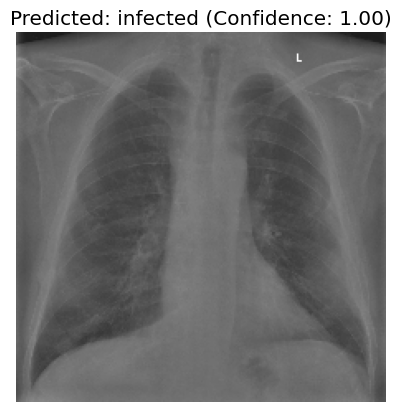

In [ ]:
#from IPython.display import Image
#Image('/content/drive/My Drive/covid dataset/images/1-s2.0-S0929664620300449-gr2_lrg-a.jpg')
image = cv2.imread('/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/infected/covid_train (10).jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = cv2.resize(image, (224, 224))
img=np.reshape(image,(1,224,224,3))
InceptionResNetV2_model.predict(img)

# Make prediction
prediction = InceptionResNetV2_model.predict(img)
predicted_class_idx = np.argmax(prediction)
predicted_label = lb.classes_[predicted_class_idx]

# Display image and prediction
plt.imshow(image)
plt.title(f"Predicted: {predicted_label} (Confidence: {prediction[0][predicted_class_idx]:.2f})")
plt.axis('off')
plt.show()

END OF INCEPTION RESNETV2